Zomato Shape: (51717, 10)
Swiggy Shape: (7559, 10)
📊 KEY METRICS SUMMARY:



,Total Restaurants,Average Rating,Avg Cost for Two (₹),Avg Visibility Index
Platform,,,,
Swiggy,4638,4.11,363.03,18.20
Zomato,41418,3.70,603.27,16.86


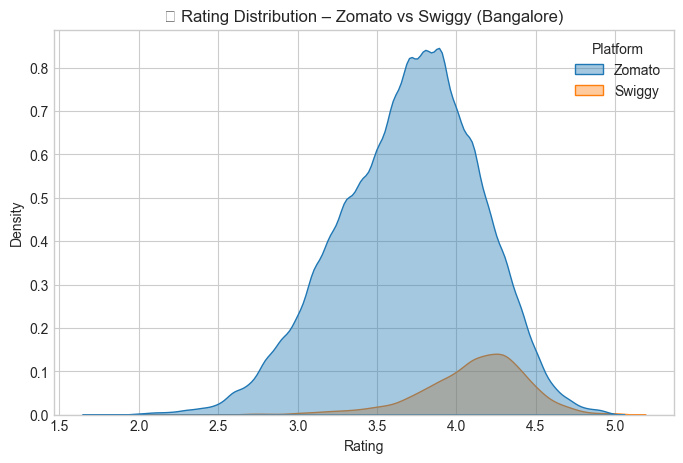

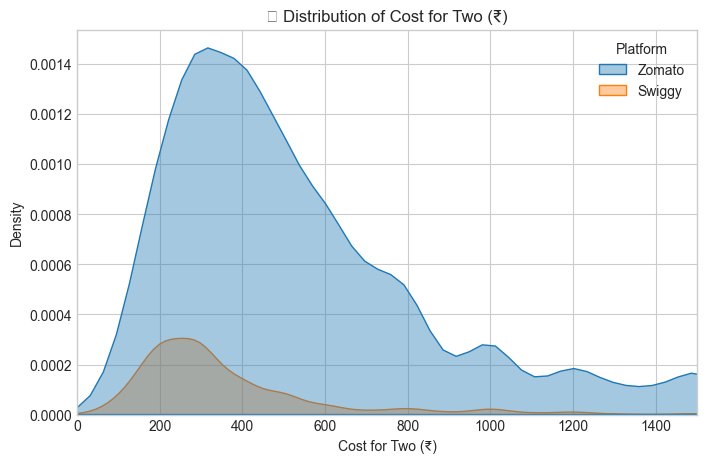

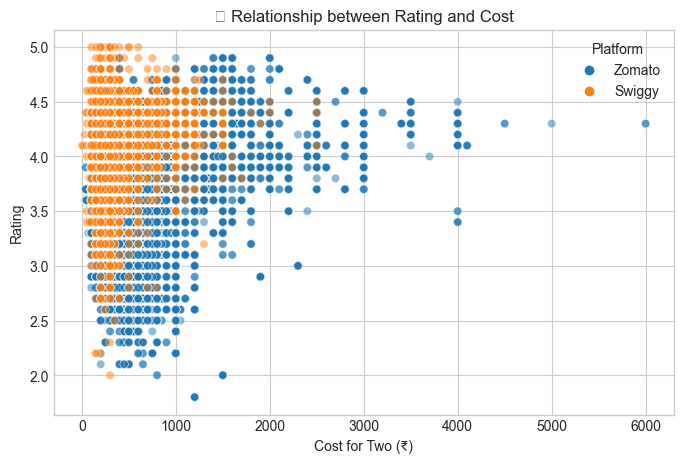

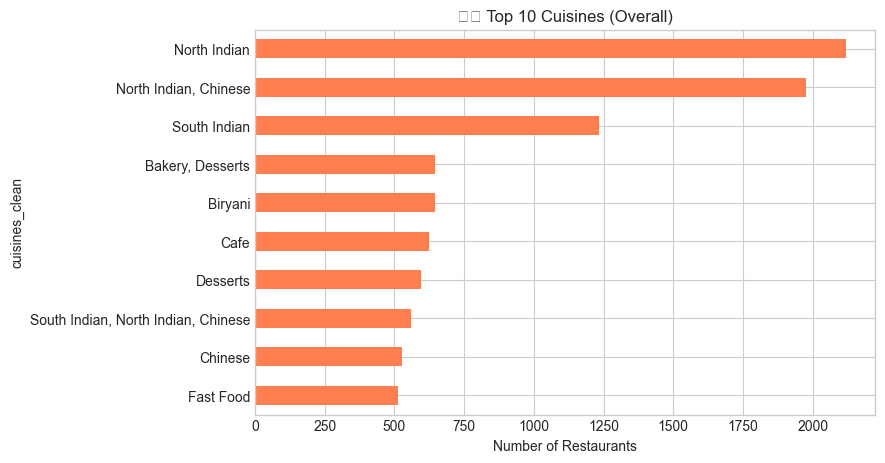

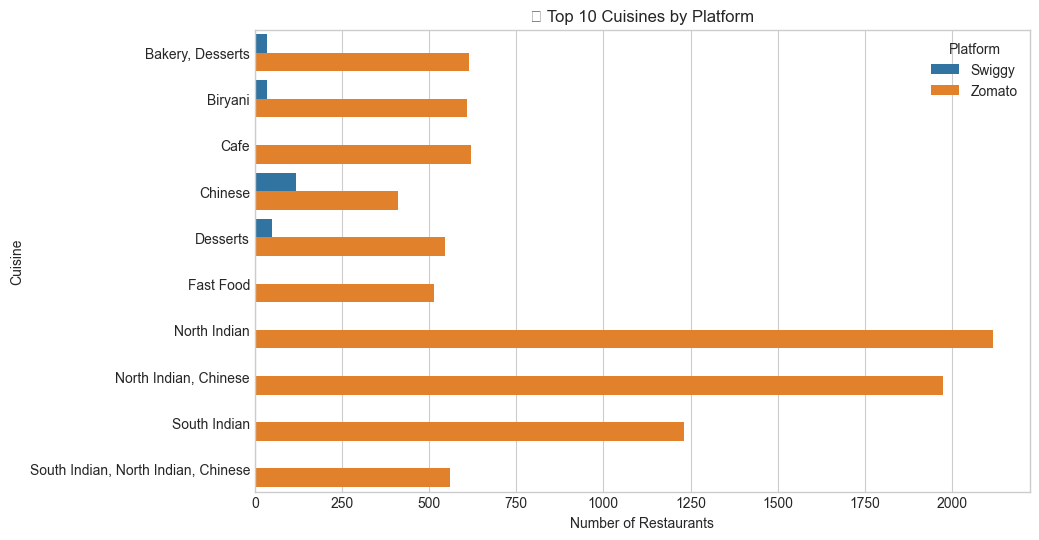

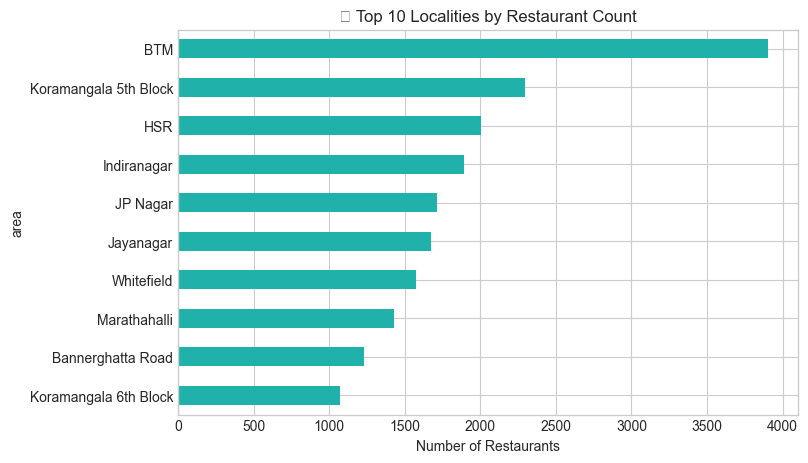


💡 Value-for-Money Index (Higher = Better):


Platform
Swiggy    0.0163
Zomato    0.0092
Name: value_for_money, dtype: float64

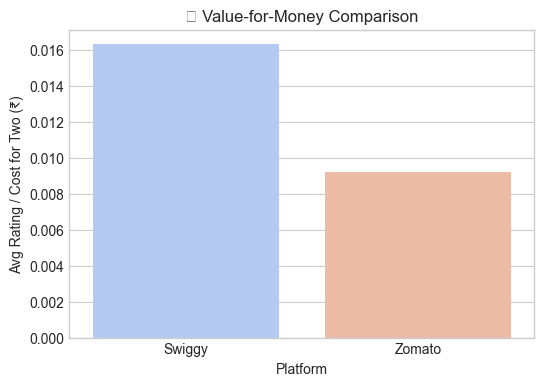

In [1]:
# -----------------------------
# 🪜 Step 1: Import Libraries
# -----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")

# -----------------------------
# 🪜 Step 2: Load Cleaned Data
# -----------------------------
zomato = pd.read_csv("../data/processed/zomato_clean.csv")
swiggy = pd.read_csv("../data/processed/swiggy_clean.csv")

# Inspect quick info
print("Zomato Shape:", zomato.shape)
print("Swiggy Shape:", swiggy.shape)

# Add platform column for merging and comparisons
zomato["Platform"] = "Zomato"
swiggy["Platform"] = "Swiggy"

# -----------------------------
# 🪜 Step 3: Standardize Columns
# -----------------------------
# Rename columns to unify schema for merged analysis
zomato_renamed = zomato.rename(columns={
    "rate_clean": "rating_clean",
    "location": "area",
    "cuisines": "cuisines_clean",
    "listed_in(city)": "city"
})[
    ["name", "city", "area", "cuisines_clean", "rating_clean", "cost_two_clean",
     "visibility_index", "Platform"]
]

swiggy_renamed = swiggy[
    ["name", "city", "area", "cuisines_clean", "rating_clean",
     "cost_two_clean", "visibility_index", "Platform"]
]

# Merge both
combined = pd.concat([zomato_renamed, swiggy_renamed], ignore_index=True)

# Handle missing values
combined["rating_clean"] = pd.to_numeric(combined["rating_clean"], errors="coerce")
combined["cost_two_clean"] = pd.to_numeric(combined["cost_two_clean"], errors="coerce")
combined["visibility_index"] = pd.to_numeric(combined["visibility_index"], errors="coerce")
combined.dropna(subset=["rating_clean", "cost_two_clean"], inplace=True)

# -----------------------------
# 🪜 Step 4: Basic KPIs
# -----------------------------
summary = combined.groupby("Platform").agg({
    "name": "count",
    "rating_clean": "mean",
    "cost_two_clean": "mean",
    "visibility_index": "mean"
}).rename(columns={
    "name": "Total Restaurants",
    "rating_clean": "Average Rating",
    "cost_two_clean": "Avg Cost for Two (₹)",
    "visibility_index": "Avg Visibility Index"
}).round(2)

print("📊 KEY METRICS SUMMARY:\n")
display(summary)

# -----------------------------
# 🪜 Step 5: Rating Distribution
# -----------------------------
plt.figure(figsize=(8,5))
sns.kdeplot(data=combined, x="rating_clean", hue="Platform", fill=True, alpha=0.4)
plt.title("⭐ Rating Distribution – Zomato vs Swiggy (Bangalore)", fontsize=12)
plt.xlabel("Rating")
plt.ylabel("Density")
plt.show()

# -----------------------------
# 🪜 Step 6: Cost Distribution
# -----------------------------
plt.figure(figsize=(8,5))
sns.kdeplot(data=combined, x="cost_two_clean", hue="Platform", fill=True, alpha=0.4)
plt.title("💰 Distribution of Cost for Two (₹)", fontsize=12)
plt.xlabel("Cost for Two (₹)")
plt.xlim(0, 1500)
plt.show()

# -----------------------------
# 🪜 Step 7: Rating vs Cost Relationship
# -----------------------------
plt.figure(figsize=(8,5))
sns.scatterplot(data=combined, x="cost_two_clean", y="rating_clean", hue="Platform", alpha=0.5)
plt.title("📈 Relationship between Rating and Cost", fontsize=12)
plt.xlabel("Cost for Two (₹)")
plt.ylabel("Rating")
plt.show()

# -----------------------------
# 🪜 Step 8: Top 10 Cuisines Overall
# -----------------------------
top_cuisines = (
    combined["cuisines_clean"]
    .value_counts()
    .head(10)
    .sort_values(ascending=True)
)

plt.figure(figsize=(8,5))
top_cuisines.plot(kind="barh", color="#FF7F50")
plt.title("🍽️ Top 10 Cuisines (Overall)", fontsize=12)
plt.xlabel("Number of Restaurants")
plt.show()

# -----------------------------
# 🪜 Step 9: Top Cuisines by Platform
# -----------------------------
top10_cuisines = combined["cuisines_clean"].value_counts().head(10).index
top_cuisines_platform = (
    combined[combined["cuisines_clean"].isin(top10_cuisines)]
    .groupby(["Platform", "cuisines_clean"])["name"]
    .count()
    .reset_index()
)

plt.figure(figsize=(10,6))
sns.barplot(data=top_cuisines_platform,
            x="name", y="cuisines_clean", hue="Platform")
plt.title("🍛 Top 10 Cuisines by Platform", fontsize=12)
plt.xlabel("Number of Restaurants")
plt.ylabel("Cuisine")
plt.legend(title="Platform")
plt.show()

# -----------------------------
# 🪜 Step 10: Top 10 Localities by Restaurant Count
# -----------------------------
top_localities = (
    combined["area"].value_counts().head(10).sort_values(ascending=True)
)

plt.figure(figsize=(8,5))
top_localities.plot(kind="barh", color="#20B2AA")
plt.title("📍 Top 10 Localities by Restaurant Count", fontsize=12)
plt.xlabel("Number of Restaurants")
plt.show()

# -----------------------------
# 🪜 Step 11: Value-for-Money Index
# -----------------------------
combined["value_for_money"] = combined["rating_clean"] / combined["cost_two_clean"]

vfm = combined.groupby("Platform")["value_for_money"].mean().round(4)
print("\n💡 Value-for-Money Index (Higher = Better):")
display(vfm)

plt.figure(figsize=(6,4))
sns.barplot(x=vfm.index, y=vfm.values, palette="coolwarm")
plt.title("💸 Value-for-Money Comparison", fontsize=12)
plt.ylabel("Avg Rating / Cost for Two (₹)")
plt.show()



In [4]:
# -----------------------------
# 🪜 Step 12: Automated Export for Power BI & Reports (Final Version)
# -----------------------------
import pandas as pd
import os

# -----------------------------
# 0️⃣ Load and Setup
# -----------------------------
combined_path = "../data/exports/combined_zomato_swiggy.csv"

# Read combined data
combined = pd.read_csv(combined_path, encoding="utf-8")

# Ensure numeric fields are correct
combined["rating_clean"] = pd.to_numeric(combined["rating_clean"], errors="coerce")
combined["cost_two_clean"] = pd.to_numeric(combined["cost_two_clean"], errors="coerce")
combined["visibility_index"] = pd.to_numeric(combined["visibility_index"], errors="coerce")

# Create export folder
export_path = "../data/exports"
os.makedirs(export_path, exist_ok=True)

# ============================================================
# 1️⃣ PLATFORM SUMMARY (overall metrics per platform)
# ============================================================
platform_summary = (
    combined.groupby("Platform", as_index=False)
    .agg(
        **{"Total Restaurants": ("name", "count")},
        **{"Average Rating": ("rating_clean", "mean")},
        **{"Avg Cost for Two (₹)": ("cost_two_clean", "mean")},
        **{"Avg Visibility Index": ("visibility_index", "mean")},
    )
    .round(2)
)

# ============================================================
# 2️⃣ FILTERED DATASETS (Swiggy & Zomato)
# ============================================================
swiggy_bangalore = combined[combined["Platform"].str.lower() == "swiggy"]
zomato_bangalore = combined[combined["Platform"].str.lower() == "zomato"]

# ============================================================
# 3️⃣ VALUE FOR MONEY (average score per platform)
# ============================================================
value_for_money = (
    combined.groupby("Platform", as_index=False)["value_for_money"]
    .mean()
    .round(4)
)

# ============================================================
# 4️⃣ CUISINE-LEVEL DATA (Exploded version)
# ============================================================
# ➤ Each restaurant offering multiple cuisines will appear in multiple rows
# ➤ This enables cuisine-level analysis in Power BI (heatmaps, overlaps, etc.)

combined_expanded = combined.assign(
    cuisine=combined["cuisines_clean"].str.split(",")  # Split the string by commas
).explode("cuisine")  # Create new row per cuisine

# Clean whitespace in cuisine names
combined_expanded["cuisine"] = combined_expanded["cuisine"].str.strip()

# Optional: remove completely blank cuisine entries
combined_expanded = combined_expanded[combined_expanded["cuisine"].notna() & (combined_expanded["cuisine"] != "")]

# ============================================================
# 5️⃣ EXPORT ALL FILES (UTF-8 with ₹ support)
# ============================================================
platform_summary.to_csv(f"{export_path}/platform_summary.csv", index=False, encoding="utf-8-sig")
swiggy_bangalore.to_csv(f"{export_path}/swiggy_bangalore.csv", index=False, encoding="utf-8-sig")
zomato_bangalore.to_csv(f"{export_path}/zomato_bangalore.csv", index=False, encoding="utf-8-sig")
value_for_money.to_csv(f"{export_path}/value_for_money.csv", index=False, encoding="utf-8-sig")
combined_expanded.to_csv(f"{export_path}/combined_cuisine_level.csv", index=False, encoding="utf-8-sig")

# ============================================================
# 6️⃣ SUMMARY LOG
# ============================================================
print(f"✅ All processed datasets exported successfully to {export_path}\n")
print("📂 Files generated:")
print("- platform_summary.csv")
print("- swiggy_bangalore.csv")
print("- zomato_bangalore.csv")
print("- value_for_money.csv")
print("- combined_cuisine_level.csv  ← cuisine-level version for Power BI")


✅ All processed datasets exported successfully to ../data/exports

📂 Files generated:
- platform_summary.csv
- swiggy_bangalore.csv
- zomato_bangalore.csv
- value_for_money.csv
- combined_cuisine_level.csv  ← cuisine-level version for Power BI
